Датасет: https://www.kaggle.com/datasets/egorkainov/moscow-housing-price-dataset

In [ ]:
# Импорт библиотек

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("dark")

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

from catboost import CatBoostRegressor, Pool, cv

In [ ]:
df = pd.read_csv('moscow_housing.csv')
df.head()

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation


Этот набор данных содержит информацию, необходимую для прогнозирования цен на жилье в Москве и Московской области. Собранные в ноябре 2023 года данные являются актуальными и пригодными для анализа. Они включают различные атрибуты, имеющие решающее значение для прогнозирования стоимости жилья, такие как местоположение, размер, удобства и другие важные факторы, влияющие на цены на недвижимость.

Задача: используя данные о ценах на жилье в Москве и Московской области, создайте модель машинного обучения для прогнозирования цен на квартиры. Ваша модель должна использовать различные атрибуты квартиры, такие как тип квартиры, близость к станциям метро, ​​размер, этаж и уровень ремонта, для прогнозирования цен на недвижимость. После создания модели проанализируйте ее эффективность и определите, какие факторы оказывают наиболее существенное влияние на цены на жилье в Москве и Московской области.

# Разведочный анализ данных

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20841 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             20841 non-null  float64
 1   Apartment type    20841 non-null  object 
 2   Metro station     20841 non-null  object 
 3   Minutes to metro  20841 non-null  float64
 4   Region            20841 non-null  object 
 5   Number of rooms   20841 non-null  float64
 6   Area              20841 non-null  float64
 7   Living area       20841 non-null  float64
 8   Kitchen area      20841 non-null  float64
 9   Floor             20841 non-null  float64
 10  Number of floors  20841 non-null  int64  
 11  Renovation        20841 non-null  object 
dtypes: float64(7), int64(1), object(4)
memory usage: 2.1+ MB


В данных могут быть аномалии. Далее в работе целевую переменную и вещественные признаки рассмотрим более подробно.

In [ ]:
df.describe()

,Price,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors
count,2.084100e+04,20841.000000,20841.000000,20841.000000,20841.000000,20841.000000,20841.000000,20841.000000
mean,3.403777e+07,11.953265,2.039681,69.705636,37.488518,12.421419,9.179358,16.588072
std,7.962198e+07,6.257113,1.487829,64.215736,35.986182,7.539409,7.477360,9.608020
min,1.150000e+06,0.000000,0.000000,6.000000,2.000000,1.000000,1.000000,1.000000
25%,7.089768e+06,7.000000,1.000000,37.160000,17.500000,8.500000,4.000000,11.000000
50%,1.147112e+07,11.000000,2.000000,52.600000,28.400000,10.600000,8.000000,16.000000
75%,2.355000e+07,15.000000,3.000000,75.500000,43.000000,14.300000,13.000000,20.000000
max,2.455020e+09,60.000000,12.000000,1117.000000,566.800000,122.000000,92.000000,97.000000


Пропущенные значения:

In [ ]:
df.isna().sum()

,0
Price,0
Apartment type,0
Metro station,0
Minutes to metro,0
Region,0
Number of rooms,0
Area,0
Living area,0
Kitchen area,0
Floor,0


## Изучение целевой переменной

Построим гистограмму и ящик с усами для целевой переменной Price для просмотра и выявления структуры и аномальных значений.

<Figure size 1000x800 with 0 Axes>

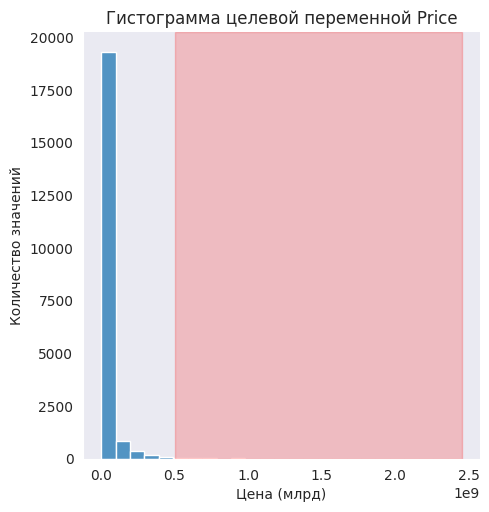

In [ ]:
plt.figure(figsize=(10, 8))

sns.displot(df.Price, bins = 25, kde=False)
plt.axvspan(0.5e9, df.Price.max(), color='red', alpha=0.2)
plt.title('Гистограмма целевой переменной Price')
plt.xlabel('Цена (млрд)')
plt.ylabel('Количество значений')
plt.show()

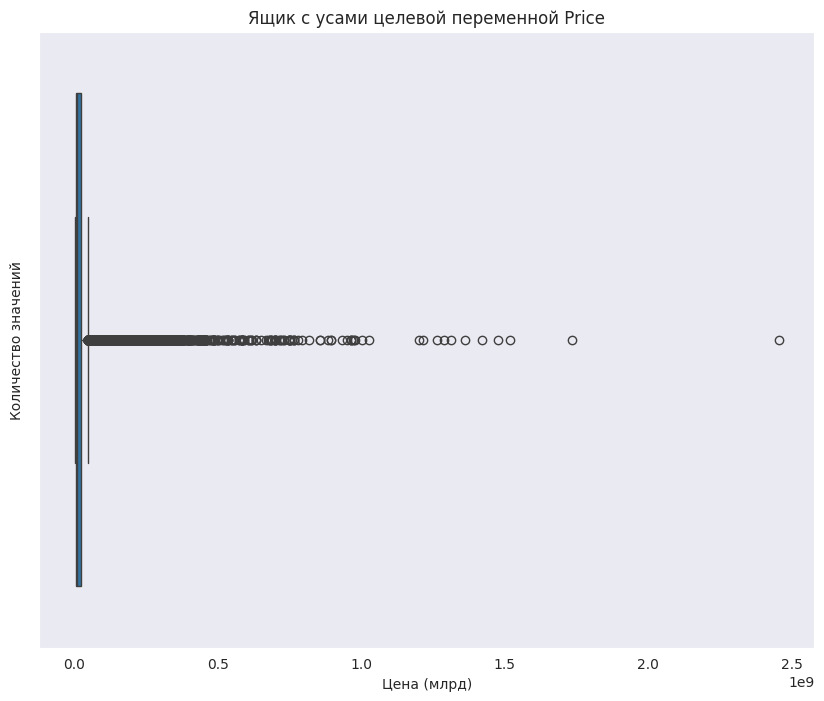

In [ ]:
plt.figure(figsize=(10, 8))

sns.boxplot(data = df, x = 'Price')

plt.title('Ящик с усами целевой переменной Price')
plt.xlabel('Цена (млрд)')
plt.ylabel('Количество значений')
plt.show()

Исследуем данные подробнее. Большинство значений распределено в небольшом диапазоне, причём чем выше ценовая категория, тем меньше таких квартир в наборе данных. Рассмотрим распределение данных от минимума цены и до 3 квартиля (примерно `2.5 * 10**7`), чтобы визуализировать распределение данных в наиболее популярной ценовой категории. И распределение данных в красной зоне (от `0.5 млрд` до максимума, примерно `2.5 млрд`), чтобы проанализировать возможные выбросы.

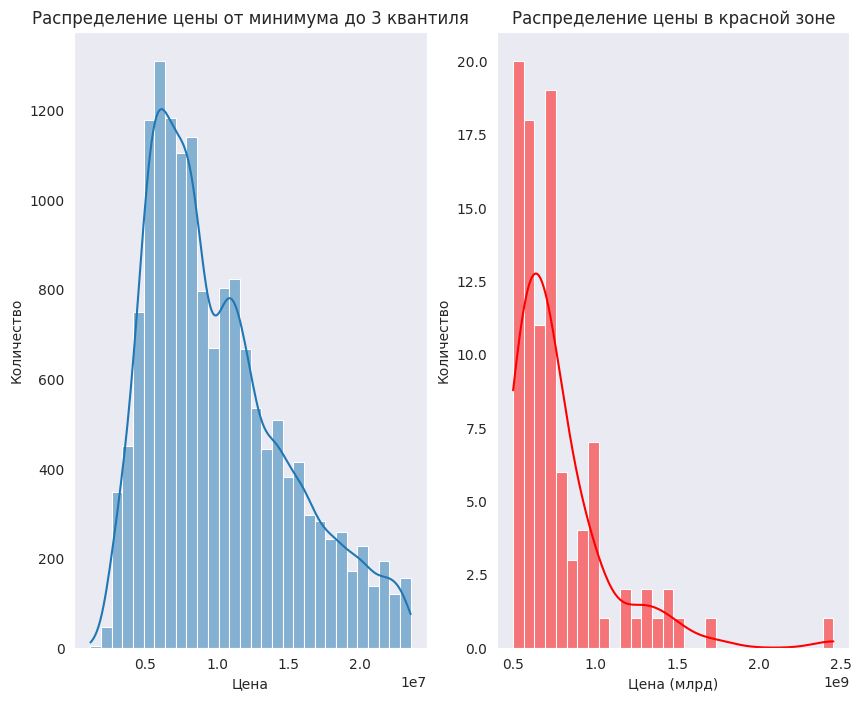

In [ ]:
area1 = df[df.Price <= df.Price.quantile(0.75)]
area2 = df[df.Price >= 0.5 * 10**9]

fig, axis = plt.subplots(1, 2, figsize=(10, 8))

sns.histplot(area1, x = area1.Price, bins = 30, kde=True, ax = axis[0])
sns.histplot(area2, x = area2.Price, bins = 30, kde=True, ax = axis[1], color='red')

axis[0].set_title('Распределение цены от минимума до 3 квартиля')
axis[0].set_xlabel('Цена')
axis[0].set_ylabel('Количество')
axis[1].set_title('Распределение цены в красной зоне')
axis[1].set_xlabel('Цена (млрд)')
axis[1].set_ylabel('Количество')

plt.show()

В данных только один объект стоит больше 2 млрд рублей, 3 объекта больше 1.5 млрд рублей. Данные квартиры имеют большую площадь и находятся в центре города. Цена может быть реалистичная для таких объектов.

In [ ]:
sum(df.Price > 2.0 * 10**9)

1

In [ ]:
sum(df.Price > 1.5 * 10**9)

3

In [ ]:
sum(df.Price > 1.0 * 10**9)

13

In [ ]:
df[df.Price > 1.5 * 10**9]

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
4090,2.455020e+09,Secondary,Маяковская,1.0,Moscow,6.0,1067.4,541.8,95.0,9.0,9,Designer
9804,1.517997e+09,Secondary,Парк культуры,8.0,Moscow,6.0,584.1,297.4,55.0,5.0,5,Designer
12840,1.732171e+09,Secondary,Охотный ряд,7.0,Moscow,0.0,719.0,300.0,50.0,5.0,5,Without renovation


In [ ]:
df[(df.Price > 1.0 * 10**9) & (df.Price < 1.5 * 10**9)]

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
933,1.200000e+09,Secondary,Баррикадная,11.0,Moscow,6.0,630.0,300.0,100.0,6.0,7,Without renovation
3702,1.028050e+09,Secondary,Полянка,5.0,Moscow,4.0,456.7,56.5,60.3,1.0,3,Designer
3897,1.475430e+09,Secondary,Площадь Революции,0.0,Moscow,5.0,657.5,334.5,61.0,1.0,5,Designer
4156,1.214256e+09,Secondary,Кропоткинская,2.0,Moscow,6.0,581.0,295.9,54.7,2.0,4,Designer
9677,1.422120e+09,Secondary,Боровицкая,14.0,Moscow,5.0,508.0,225.0,25.0,4.0,4,Without renovation
10088,1.289324e+09,Secondary,Лужники,8.0,Moscow,6.0,529.8,400.0,30.0,1.0,7,Designer
10133,1.003158e+09,Secondary,Парк культуры,10.0,Moscow,6.0,431.0,220.0,42.3,5.0,6,Without renovation
11171,1.313368e+09,Secondary,Баррикадная,11.0,Moscow,10.0,630.0,320.6,58.8,6.0,6,Designer
11380,1.362011e+09,Secondary,Парк культуры,8.0,Moscow,6.0,584.1,285.0,25.0,5.0,5,Designer
11414,1.264998e+09,Secondary,Баррикадная,11.0,Moscow,6.0,640.0,250.0,70.0,6.0,6,Without renovation


Принято решение заменить цену на этих объектах на более низкую (`1.0 * 10**9`).

In [ ]:
df.loc[df.Price > 1.5 * 10**9, 'Price'] = 1.0 * 10**9

In [ ]:
df[df.Price > 1.5 * 10**9]

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation


## Изучение категориальных признаков

In [ ]:
info_df = pd.DataFrame()
info_df['Data Type'] = df.dtypes
info_df['Unique'] = df.nunique()
info_df

,Data Type,Unique
Price,float64,9977
Apartment type,object,2
Metro station,object,547
Minutes to metro,float64,56
Region,object,2
Number of rooms,float64,12
Area,float64,3017
Living area,float64,1302
Kitchen area,float64,481
Floor,float64,72


У трёх из четырёх категориальных признаков небольшое количество уникальных значений. Визуализируем их рапределение с помощью столбчатой диаграммы.

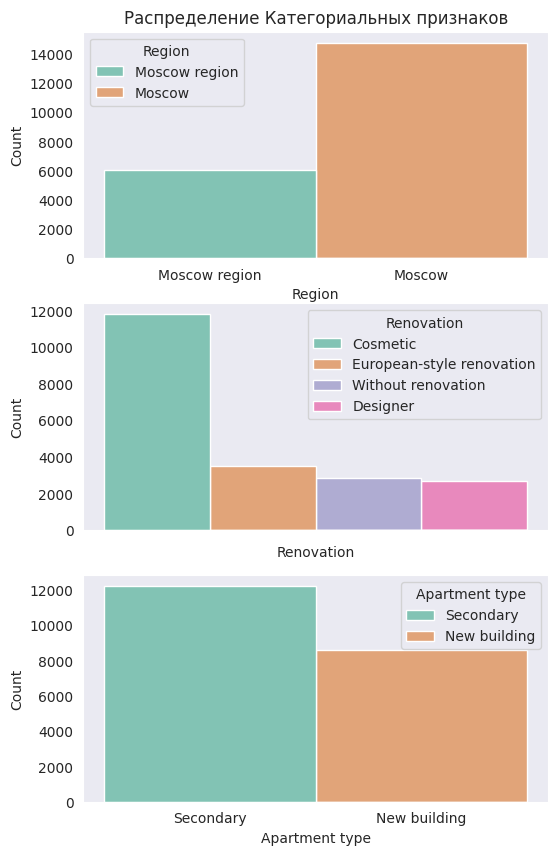

In [ ]:
fig, axis = plt.subplots(3, 1, figsize=(6, 10))

sns.histplot(data = df, x = 'Region', hue = "Region", palette = "Dark2", ax=axis[0])
sns.histplot(data = df, x = 'Renovation', hue = "Renovation", palette = "Dark2", ax=axis[1])
sns.histplot(data = df, x = 'Apartment type', hue = "Apartment type", palette = "Dark2", ax=axis[2])

axis[0].set_title('Распределение Категориальных признаков')
axis[1].set(xticklabels=[])

plt.show()

В столбце "**Metro station**" много уникальных значений. Приведём все к нижнему регистру и уберём лишние пробелы, чтобы избавиться от возможных дубликатов.

In [ ]:
df['Metro station'].unique()[:15]

array([' Опалиха', ' Павшино', ' Мякинино', ' Строгино', ' Нахабино',
       ' Красногорская', ' Тушинская', ' Аникеевка', ' Волоколамская',
       ' Пенягино', ' Митино', ' Пятницкое шоссе', ' Чеховская',
       ' Арбатская', ' Фили'], dtype=object)

In [ ]:
df['Metro station'] = df['Metro station'].str.lower()
df['Metro station'] = df['Metro station'].str.strip()

In [ ]:
df['Metro station'].unique()[:15]

array(['опалиха', 'павшино', 'мякинино', 'строгино', 'нахабино',
       'красногорская', 'тушинская', 'аникеевка', 'волоколамская',
       'пенягино', 'митино', 'пятницкое шоссе', 'чеховская', 'арбатская',
       'фили'], dtype=object)

В Москве примерно 430 станций с учётом МЦД и МЦК. После избавления от дубликатов в столбце осталось 310 уникальных значений.

In [ ]:
df['Metro station'].nunique()

310

Рассмотрим распределение наиболее популярых станций метро для наших объектов.

In [ ]:
metro_count = df.groupby('Metro station').count().Price
metro_count = metro_count.rename('Count')
metro_count = metro_count.sort_values(ascending=False).head(9).to_frame()
metro_count

,Count
Metro station,
красногвардейская,2418
депо,1395
братиславская,1001
котельники,952
жулебино,720
зябликово,635
битца,321
опалиха,291
каширская,286


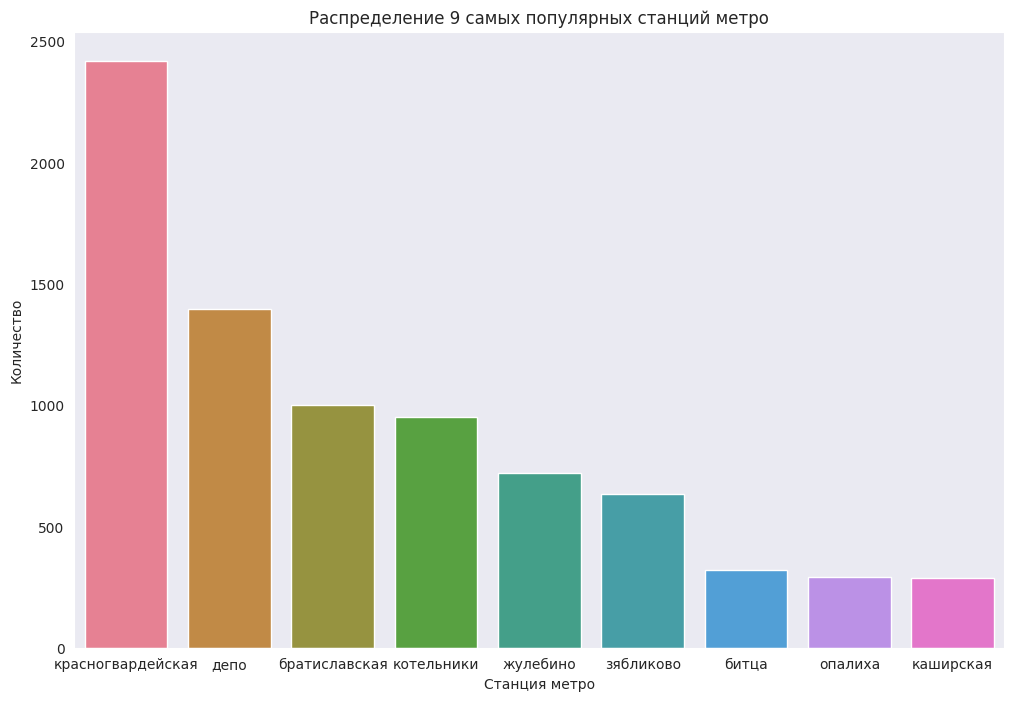

In [ ]:
plt.figure(figsize=(12, 8))

sns.barplot(data = metro_count, x = 'Metro station', y = 'Count', hue = "Metro station", palette = "husl")

plt.xlabel('Станция метро')
plt.ylabel('Количество')
plt.title(f'Распределение {len(metro_count)} самых популярных станций метро')
plt.show()

## Изучение вещественных признаков

Для всех вещественных признаков построим гистограммы и ящики с усами для просмотра распределения данных и анализа возможных выбросов.

In [ ]:
numerical = df.describe().columns
numerical = numerical.delete(0)
numerical

Index(['Minutes to metro', 'Number of rooms', 'Area', 'Living area',
       'Kitchen area', 'Floor', 'Number of floors'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

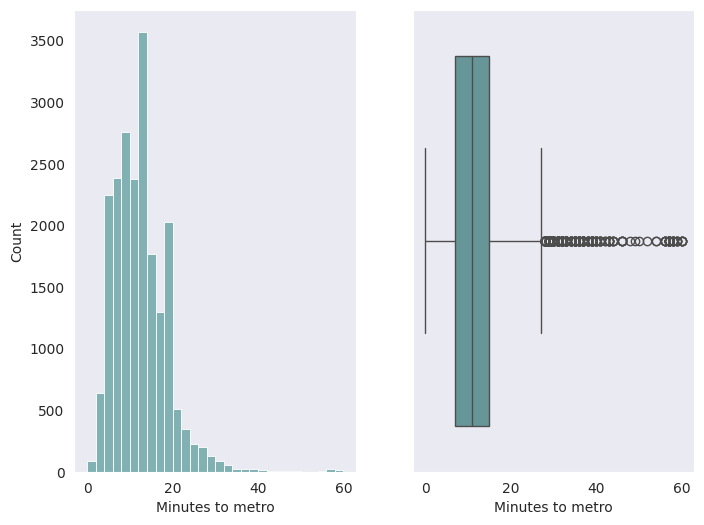

<Figure size 640x480 with 0 Axes>

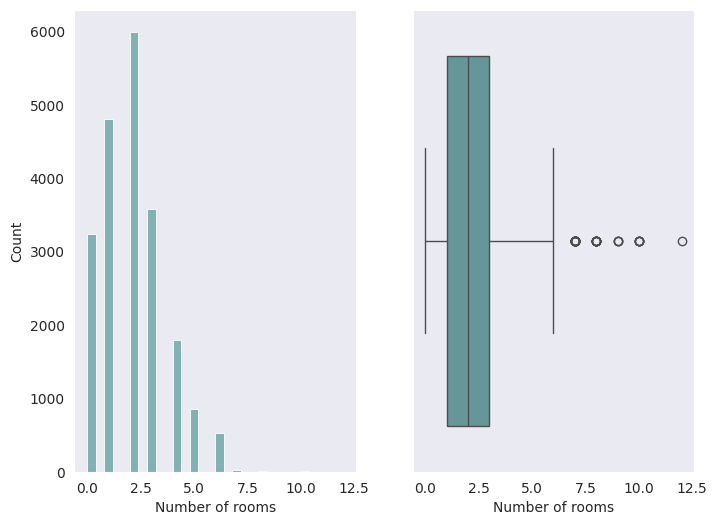

<Figure size 640x480 with 0 Axes>

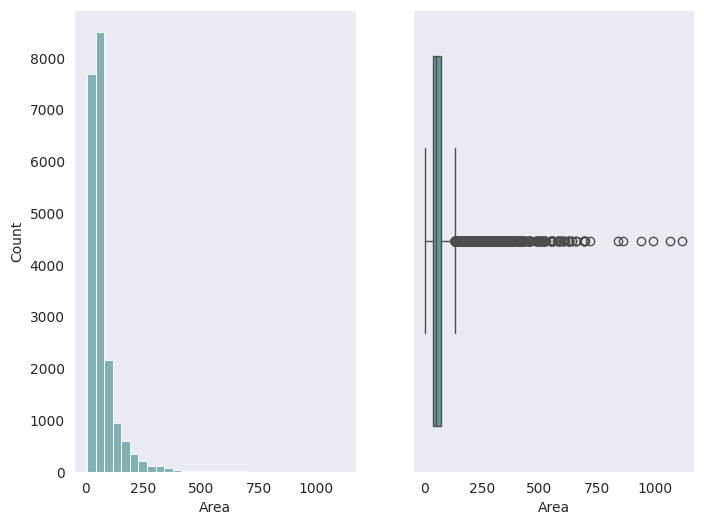

<Figure size 640x480 with 0 Axes>

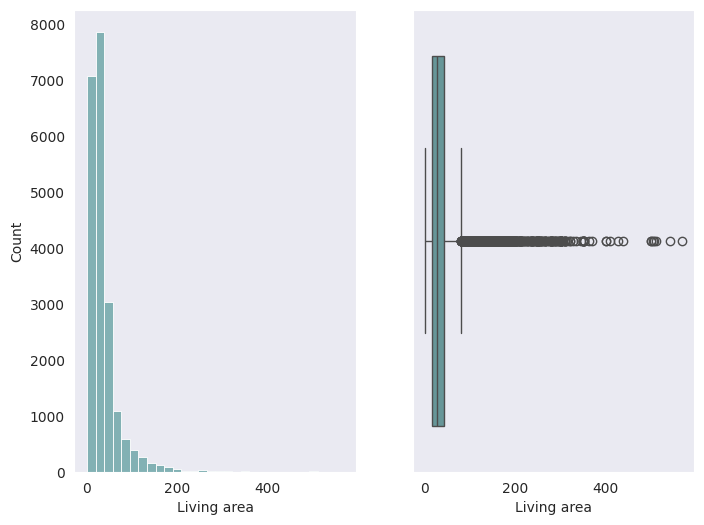

<Figure size 640x480 with 0 Axes>

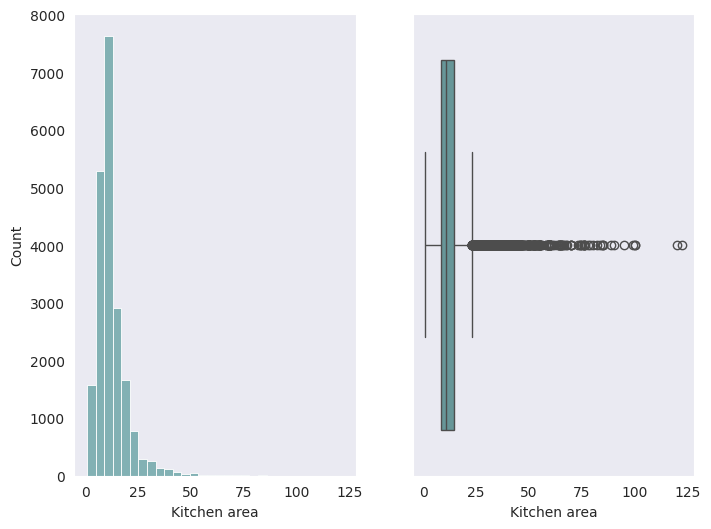

<Figure size 640x480 with 0 Axes>

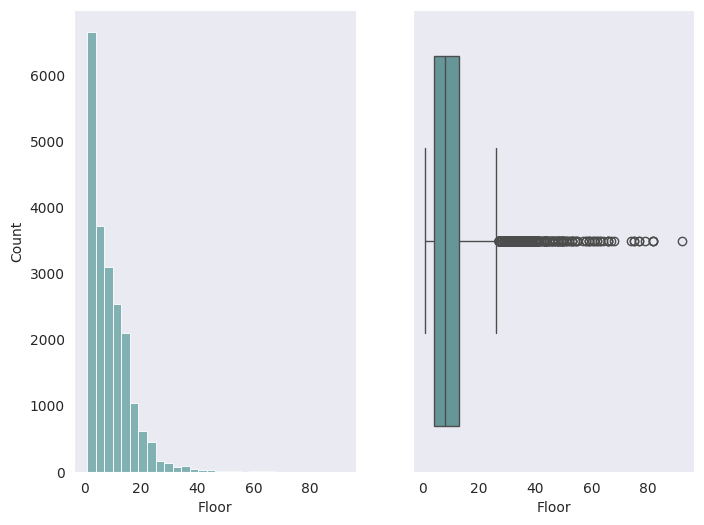

<Figure size 640x480 with 0 Axes>

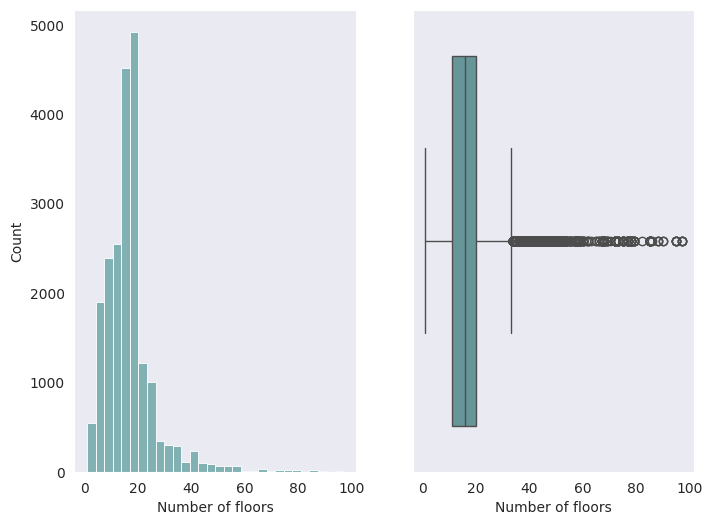

In [ ]:
for col in numerical:
    fig = plt.figure()
    fig, ax = plt.subplots(1, 2, figsize = (8, 6))
    sns.histplot(data=df, x = col, color='cadetblue', bins=30, ax=ax[0])
    sns.boxplot(data=df, x = col, color = 'cadetblue', ax=ax[1])
    plt.show()

Распределение данных довольно схоже между собой. Скорее всего большие значения не являются аномалиями и объясняются природой данных. Просмотрим объекты с большими значеними остальных переменных, чтобы проанализировать их.

In [ ]:
df[df['Number of rooms'] > 9]

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
9912,8.100000e+07,Secondary,марксистская,8.0,Moscow,12.0,268.0,200.0,15.0,2.0,2,Designer
10658,5.780000e+08,Secondary,кропоткинская,10.0,Moscow,10.0,612.0,362.2,35.9,2.0,5,Designer
10698,2.100000e+08,Secondary,китай-город,11.0,Moscow,10.0,607.0,300.0,15.0,2.0,3,Designer
10867,3.625000e+08,Secondary,деловой центр,1.0,Moscow,10.0,353.0,200.0,50.0,82.0,97,Designer
11140,1.850000e+08,Secondary,киевская,11.0,Moscow,10.0,335.0,208.0,17.0,6.0,6,Designer
11171,1.313368e+09,Secondary,баррикадная,11.0,Moscow,10.0,630.0,320.6,58.8,6.0,6,Designer


In [ ]:
df[df['Area'] > 750]

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
898,5.000000e+08,Secondary,октябрьское поле,8.0,Moscow,6.0,840.0,426.8,76.1,1.0,3,Without renovation
910,5.169000e+08,Secondary,народное ополчение,5.0,Moscow,6.0,861.5,437.7,77.9,1.0,3,Designer
1385,2.700000e+08,Secondary,новокузнецкая,3.0,Moscow,0.0,1117.0,566.8,99.1,3.0,12,Without renovation
1417,5.200000e+08,Secondary,международная,4.0,Moscow,0.0,993.6,504.4,88.8,30.0,95,Without renovation
2709,5.000000e+08,Secondary,выставочная,5.0,Moscow,6.0,941.7,20.0,84.6,59.0,60,Designer
4090,1.000000e+09,Secondary,маяковская,1.0,Moscow,6.0,1067.4,541.8,95.0,9.0,9,Designer


In [ ]:
df[df['Living area'] > 450]

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
1385,2.700000e+08,Secondary,новокузнецкая,3.0,Moscow,0.0,1117.0,566.8,99.1,3.0,12,Without renovation
1417,5.200000e+08,Secondary,международная,4.0,Moscow,0.0,993.6,504.4,88.8,30.0,95,Without renovation
2708,4.000000e+08,Secondary,киевская,8.0,Moscow,6.0,578.4,504.9,20.0,5.0,5,Without renovation
4090,1.000000e+09,Secondary,маяковская,1.0,Moscow,6.0,1067.4,541.8,95.0,9.0,9,Designer
10387,5.838450e+08,Secondary,шаболовская,9.0,Moscow,6.0,658.0,500.0,60.0,18.0,20,Designer
10755,5.837190e+08,Secondary,шаболовская,8.0,Moscow,6.0,602.8,510.0,40.0,18.0,20,Designer
10956,3.113168e+08,Secondary,давыдково,24.0,Moscow,8.0,625.0,500.0,45.0,8.0,9,European-style renovation


In [ ]:
df[df['Kitchen area'] > 100]

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
10746,129000000.0,Secondary,новаторская,4.0,Moscow,6.0,628.0,247.0,120.0,30.0,30,Designer
10977,159300000.0,Secondary,терехово,46.0,Moscow,4.0,267.0,137.1,122.0,3.0,4,Designer


In [ ]:
df.Floor = df.Floor.astype(int)

In [ ]:
df[df['Floor'] > 60]

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
641,209250000.0,Secondary,международная,6.0,Moscow,4.0,225.00,100.0,50.0,63,79,Designer
643,532500000.0,Secondary,деловой центр,4.0,Moscow,4.0,426.00,350.0,41.9,66,73,Designer
817,264600000.0,Secondary,деловой центр,1.0,Moscow,5.0,270.00,138.6,29.0,92,95,Designer
987,325000000.0,Secondary,деловой центр,2.0,Moscow,6.0,355.00,210.0,36.0,82,95,Without renovation
1340,129500000.0,Secondary,деловой центр,1.0,Moscow,0.0,188.50,97.4,22.2,75,95,Designer
1416,235000000.0,Secondary,деловой центр,3.0,Moscow,0.0,353.20,280.0,40.0,82,95,Without renovation
1912,149000000.0,Secondary,международная,6.0,Moscow,2.0,111.00,70.0,30.0,62,77,Designer
1995,149000000.0,Secondary,деловой центр,5.0,Moscow,2.0,113.00,59.3,16.0,63,79,Designer
3530,109001377.0,Secondary,выставочная,1.0,Moscow,3.0,154.30,115.3,19.4,62,85,Designer
3713,173956500.0,Secondary,выставочная,1.0,Moscow,4.0,232.50,153.4,25.9,75,85,Designer


In [ ]:
df[df['Number of floors'] > 89]

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
817,264600000.0,Secondary,деловой центр,1.0,Moscow,5.0,270.0,138.6,29.0,92,95,Designer
852,115000000.0,Secondary,деловой центр,4.0,Moscow,6.0,189.0,50.0,22.3,40,90,Designer
987,325000000.0,Secondary,деловой центр,2.0,Moscow,6.0,355.0,210.0,36.0,82,95,Without renovation
1340,129500000.0,Secondary,деловой центр,1.0,Moscow,0.0,188.5,97.4,22.2,75,95,Designer
1416,235000000.0,Secondary,деловой центр,3.0,Moscow,0.0,353.2,280.0,40.0,82,95,Without renovation
1417,520000000.0,Secondary,международная,4.0,Moscow,0.0,993.6,504.4,88.8,30,95,Without renovation
2619,113400000.0,Secondary,деловой центр,4.0,Moscow,6.0,189.0,50.0,22.3,40,90,Designer
8587,134000000.0,Secondary,деловой центр,1.0,Moscow,3.0,180.0,93.1,70.0,74,97,Without renovation
10775,243000000.0,Secondary,деловой центр,1.0,Moscow,4.0,175.3,90.8,21.1,40,97,European-style renovation
10867,362500000.0,Secondary,деловой центр,1.0,Moscow,10.0,353.0,200.0,50.0,82,97,Designer


Данные выглядят реалистично для Москвы. Проверим, есть ли несоответсвие в данных. Сначала просмотрим данные, где этаж квартиры больше, чем количество жилых этажей в доме. Прибавим к количеству этажей 2, чтобы не учитывать те объявления, где первые этажи отданы под магазины и не посчитаны как жилые. Затем, где площадь кухни и жилой площади больше общей площади квартиры.

In [ ]:
unrealistic_floors = df[df.Floor > df['Number of floors'] + 2]
unrealistic_floors

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
4417,21200000.0,Secondary,марьина роща,5.0,Moscow,1.0,43.0,21.1,9.8,16,5,Designer
4460,19100000.0,Secondary,народное ополчение,12.0,Moscow,1.0,42.4,14.5,15.4,18,5,Without renovation
4781,19000000.0,Secondary,динамо,8.0,Moscow,1.0,40.0,20.0,9.0,10,6,European-style renovation
4802,19900000.0,Secondary,динамо,8.0,Moscow,1.0,39.0,25.0,10.0,9,6,Without renovation
5002,17400000.0,Secondary,народное ополчение,12.0,Moscow,1.0,33.0,22.0,8.0,8,5,Designer
...,...,...,...,...,...,...,...,...,...,...,...,...
22311,11839340.0,New building,кантемировская,20.0,Moscow,2.0,50.9,20.7,17.9,24,14,Cosmetic
22316,12605340.0,New building,кантемировская,4.0,Moscow,2.0,53.8,24.1,18.9,19,14,Cosmetic
22320,8500000.0,New building,котельники,12.0,Moscow region,1.0,41.0,21.4,10.0,25,17,Cosmetic
22639,16096250.0,New building,аннино,7.0,Moscow,2.0,81.0,43.1,13.3,38,22,Cosmetic


Жилая площадь квартиры не включает в себя площадь кухни. Общая площадь содержит в себе площадь кухни, санузлов и всех жилых комнат. При верно заполненных данных Общая площадь должна быть больше Жилой площади и Кухонной площади вместе

In [ ]:
unrealistic_area = df[(df['Living area'] + df['Kitchen area']) > df.Area]
unrealistic_area

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
55,6300000.0,Secondary,пенягино,8.0,Moscow region,1.0,19.50,12.0,8.3,2,22,Designer
805,180000000.0,Secondary,минская,14.0,Moscow,5.0,178.00,165.0,21.4,6,8,Without renovation
929,417450000.0,Secondary,минская,13.0,Moscow,6.0,379.50,370.0,38.0,5,6,Without renovation
1347,60000000.0,Secondary,ростокино,11.0,Moscow,0.0,157.00,157.0,19.6,35,38,Without renovation
1366,26500000.0,Secondary,сходненская,17.0,Moscow,0.0,62.00,62.0,11.8,1,5,Without renovation
...,...,...,...,...,...,...,...,...,...,...,...,...
22491,3906101.0,New building,красногвардейская,11.0,Moscow region,0.0,21.36,14.6,8.4,8,20,Cosmetic
22492,3860028.0,New building,красногвардейская,11.0,Moscow region,0.0,21.36,14.6,8.4,3,20,Cosmetic
22493,3848985.0,New building,красногвардейская,11.0,Moscow region,0.0,21.36,14.6,8.4,2,20,Cosmetic
22494,3830615.0,New building,красногвардейская,11.0,Moscow region,0.0,21.36,14.6,8.4,2,20,Cosmetic


Таких данных довольно много, но только шесть объектов попадают под оба нереалистичных условия.

In [ ]:
pd.merge(unrealistic_floors, unrealistic_area, how='inner')

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,3915895.0,New building,жулебино,13.0,Moscow region,0.0,23.89,15.5,8.6,17,14,Cosmetic
1,8950000.0,New building,братиславская,9.0,Moscow,1.0,35.70,20.2,17.0,22,16,Cosmetic
2,4382908.0,New building,жулебино,13.0,Moscow region,0.0,24.57,16.0,8.7,17,14,Cosmetic
3,5000000.0,New building,битца,12.0,Moscow region,0.0,24.46,14.5,12.5,12,9,Cosmetic
4,4528657.0,New building,жулебино,13.0,Moscow region,0.0,24.57,16.0,8.7,17,14,Cosmetic
5,7150000.0,New building,котельники,17.0,Moscow region,1.0,35.70,20.2,17.0,25,17,Cosmetic


Несоответствие номера этажа и количества этажей можно объяснить наличием нежилых этажей в доме. Несоответствие Общей и жилой площади - ошиибкой измерений, наличием студий в датасете или неверно заполненными или округлёнными данными. Будем иметь в виду наличие таких несоответствий при дальнейшем анализе.

## Выявление звисимостей между признаками

Выведем матрицу корреляции:

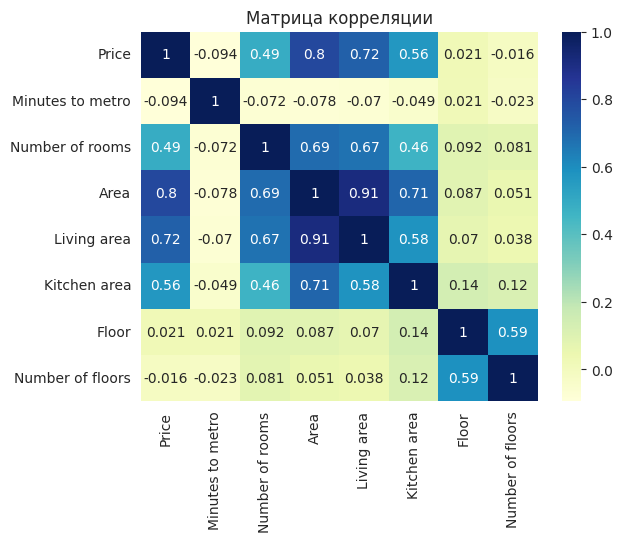

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title('Матрица корреляции')
plt.show()

Прослеживается сильная корреляция между признаками "Жилая площадь" (Living Area) и "Площадь кухни" (Kitchen Area) с признаком "Общая площадь" (Area). Рассмотрим графики этих зависимостей.

<Figure size 1000x800 with 0 Axes>

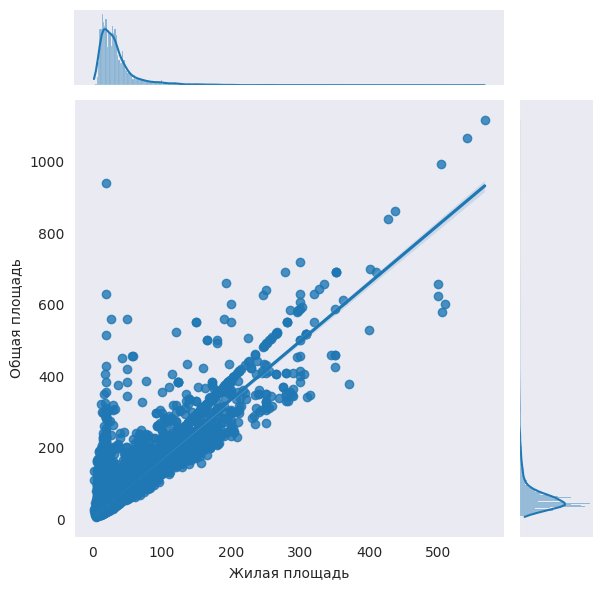

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.jointplot(data=df, x=df['Living area'], y=df['Area'], kind="reg")

plt.xlabel('Жилая площадь')
plt.ylabel('Общая площадь')
plt.show()

<Figure size 1000x800 with 0 Axes>

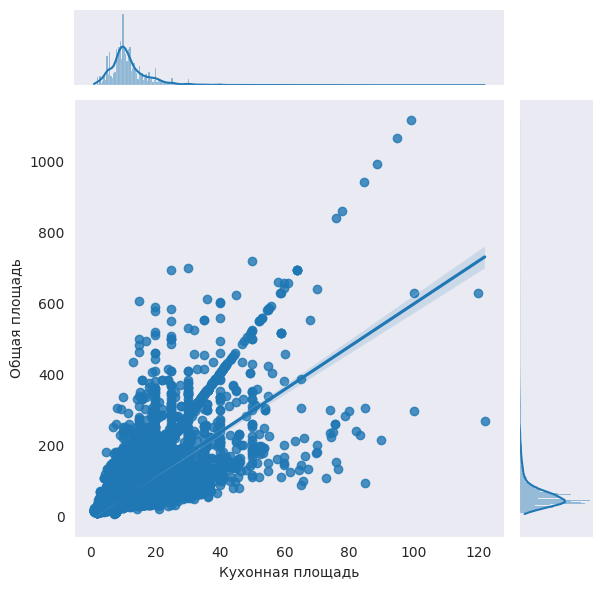

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.jointplot(data=df, x=df['Kitchen area'], y=df['Area'], kind='reg')

plt.xlabel('Кухонная площадь')
plt.ylabel('Общая площадь')
plt.show()

Так же рассмотрим график зависимости Площади кухни и Жилой площади. Корреляция между этими признаками умеренная.

<Figure size 1000x800 with 0 Axes>

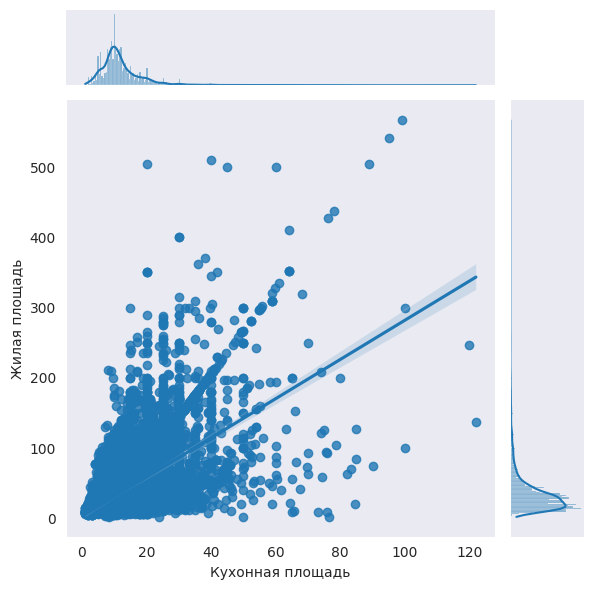

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.jointplot(data=df, x=df['Kitchen area'], y=df['Living area'], kind='reg')

plt.xlabel('Кухонная площадь')
plt.ylabel('Жилая площадь')
plt.show()

Общая площадь больше коррелирует с таргетом, соответственно является более существенным признаком для нашей модели. Но в связи с выявленными выше несоответствиями данных принято решение избавиться от него и оставить два других признака для построения базовой модели. При дальнейшей работой над моделью можно преобразовать линейную зависимость в нелинейную и протестировать модель, обученную на таком датасете.

In [ ]:
df = df.drop('Area', axis=1)

In [ ]:
numerical.delete(2)

Index(['Minutes to metro', 'Number of rooms', 'Living area', 'Kitchen area',
       'Floor', 'Number of floors'],
      dtype='object')

## Влияние признаков на целевую переменную

Проанализируем корреляцию признаков с таргетом Price. Посмотрим на графики зависимостей цены и двух признаков с большим коэффициентом корреляции 'Living area' и 'Kitchen area'

<Figure size 1000x800 with 0 Axes>

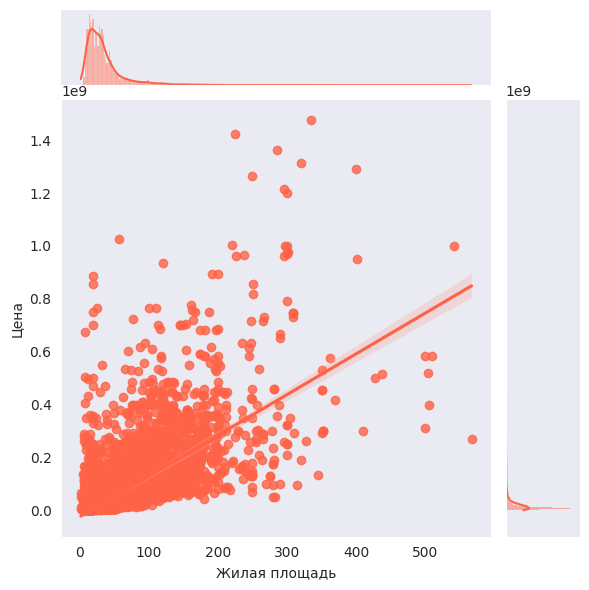

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.jointplot(data=df, x=df['Living area'], y=df['Price'], kind='reg', color='tomato')

plt.xlabel('Жилая площадь')
plt.ylabel('Цена')
plt.show()

<Figure size 1000x800 with 0 Axes>

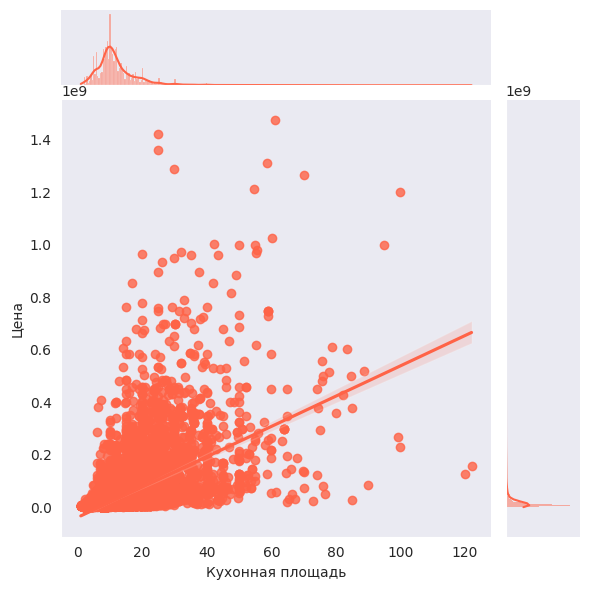

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.jointplot(data=df, x=df['Kitchen area'], y=df['Price'], kind='reg', color='tomato')

plt.xlabel('Кухонная площадь')
plt.ylabel('Цена')
plt.show()

Посмотрим на зависимость цены от придзнаков с меньшим коэффициентом корреляции. Чем больше количество этажей в доме и чем дальше дом удалён от метро, тем меньше у таких квартир разброс в цене. Большинство объектов с большой стоимостью находятся на наименьшем удалении от метро и в небольших и средних домах (до 15 этажей).

<Figure size 1000x800 with 0 Axes>

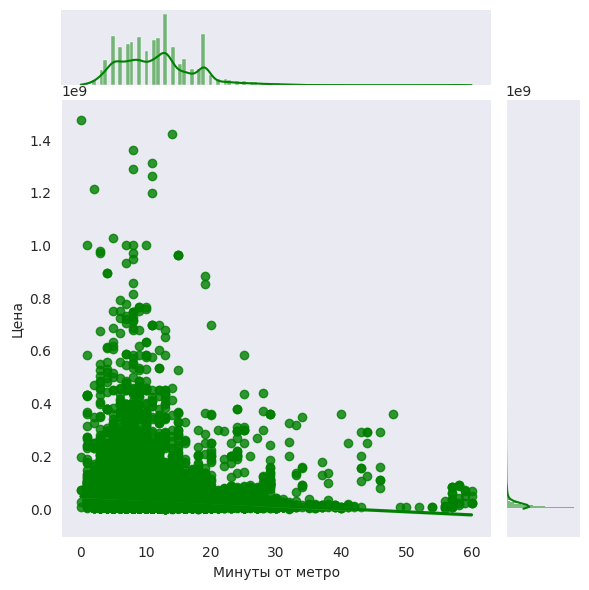

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.jointplot(data=df, x=df['Minutes to metro'], y=df['Price'], kind='reg', color='green')

plt.xlabel('Минуты от метро')
plt.ylabel('Цена')
plt.show()

<Figure size 1000x800 with 0 Axes>

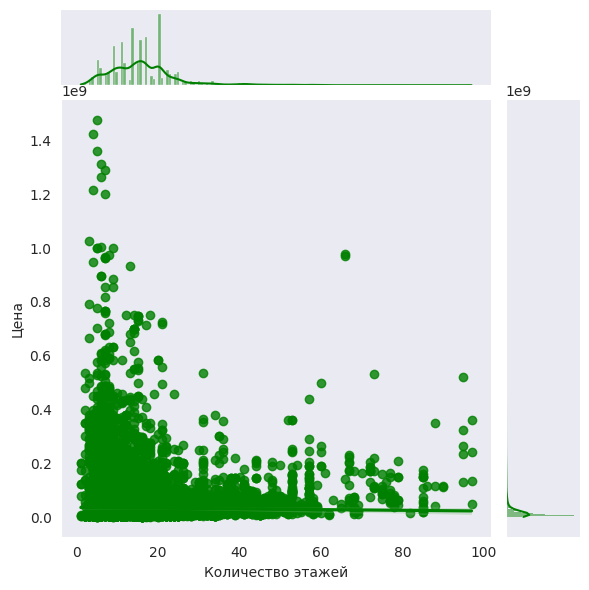

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.jointplot(data=df, x=df['Number of floors'], y=df['Price'],kind='reg', color='green')

plt.xlabel('Количество этажей')
plt.ylabel('Цена')
plt.show()

Далее посмотрим зависимость таргета от категориальных признаков. Для этого построим графики violinplot для трех признаков с небольшим количеством уникальных значений.

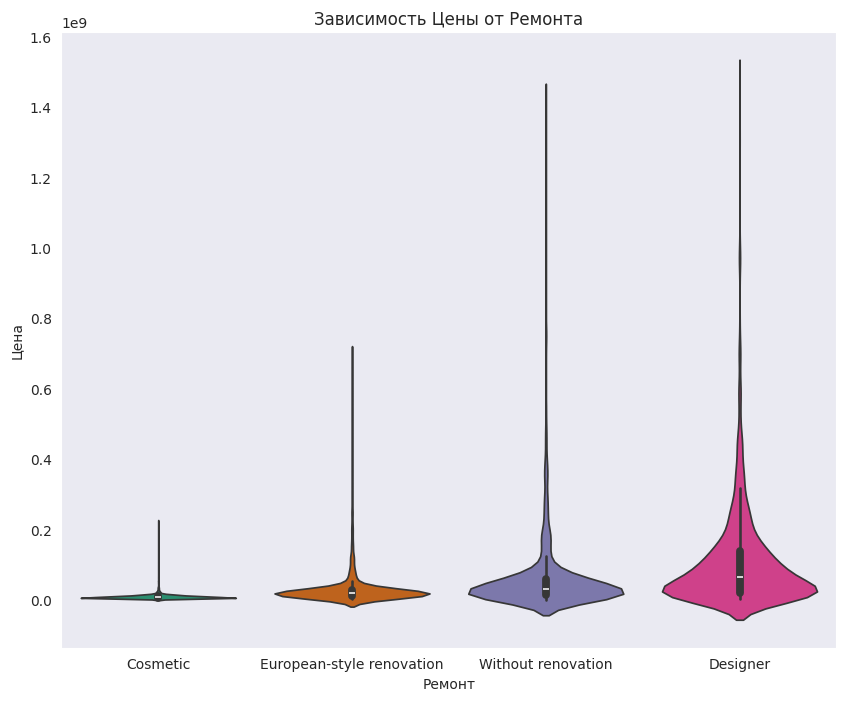

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.violinplot(data=df, x="Renovation", y="Price", palette="Dark2")

plt.title('Зависимость Цены от Ремонта')
plt.xlabel('Ремонт')
plt.ylabel('Цена')
plt.show()

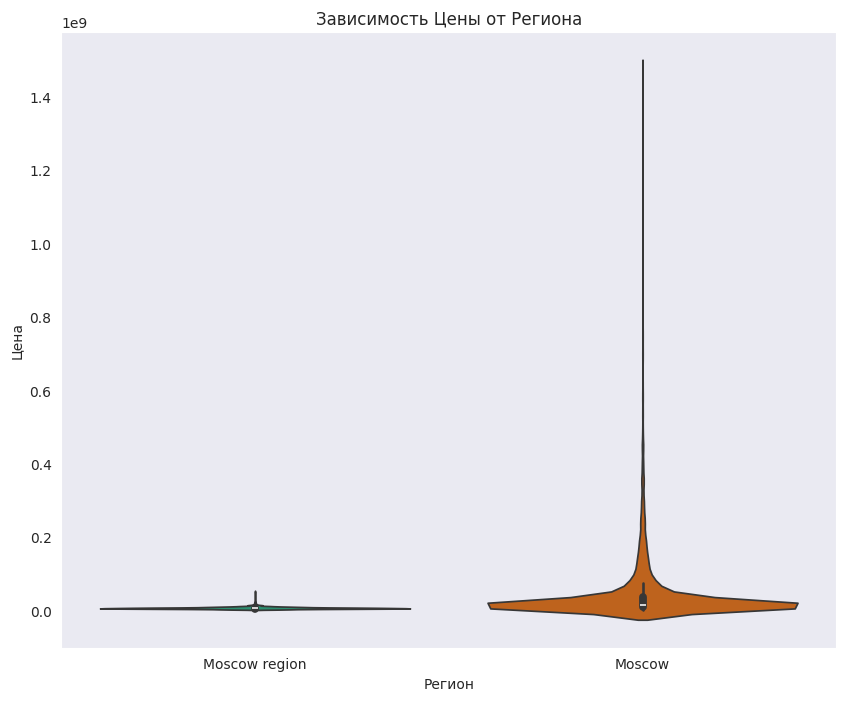

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.violinplot(data=df, x="Region", y="Price", palette="Dark2")

plt.title('Зависимость Цены от Региона')
plt.xlabel('Регион')
plt.ylabel('Цена')
plt.show()

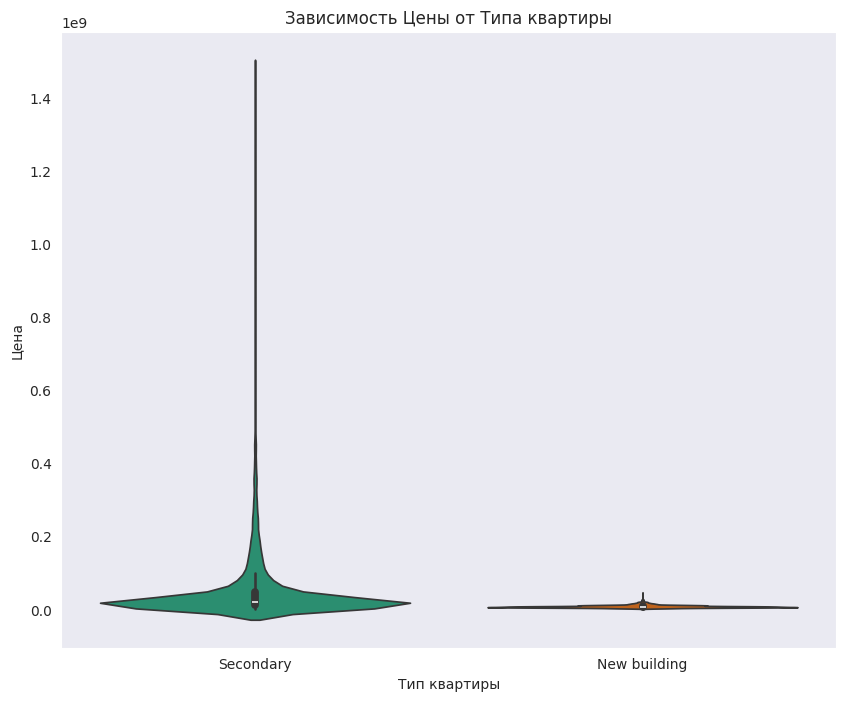

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.violinplot(data=df, x="Apartment type", y="Price", palette="Dark2")

plt.title('Зависимость Цены от Типа квартиры')
plt.xlabel('Тип квартиры')
plt.ylabel('Цена')
plt.show()

Все данные признаки сильно влияют на цену. Так же у объектов в новых домах, домах в регионах и квартир с косметическим ремонтом небольшое количество выбросов.

Выведем график зависимости цены от станций метро. Так как станций очень много, найдём топ 30 наиболее встречающихся станций. С таким набором данных сложно оценить наличие зависимости.

In [ ]:
top_stations = df.groupby('Metro station').count().Price.sort_values(ascending=False).head(30)
df_metro = df.copy()
df_metro = df_metro.merge(top_stations, how='right', on='Metro station')

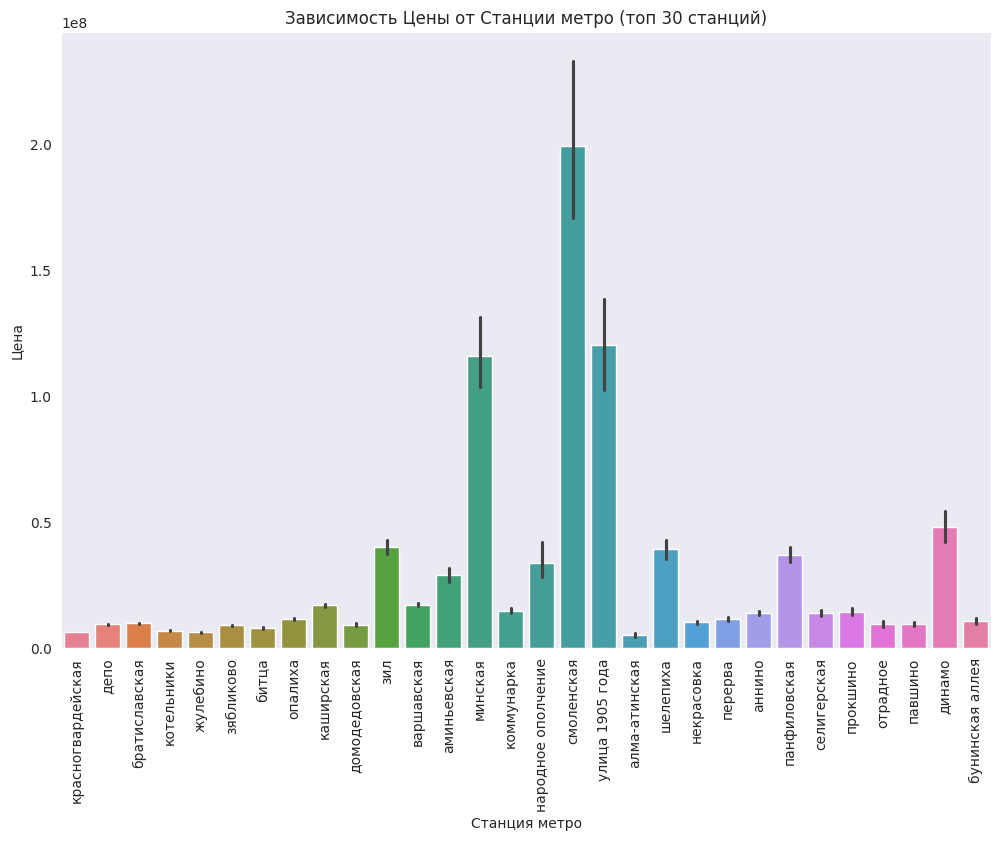

In [ ]:
plt.figure(figsize=(12, 8))

sns.barplot(data = df_metro, x = 'Metro station', y = 'Price_x', hue = "Metro station", palette = "husl")

plt.xlabel('Станция метро')
plt.ylabel('Цена')
plt.title(f'Зависимость Цены от Станции метро (топ 30 станций)')
plt.xticks(rotation=90)
plt.show()

# Построение модели

## Подготовка данных к построению модели

In [ ]:
categorical = df.describe(include='object')
categorical = list(categorical.columns)

In [ ]:
X = df.copy()
X.drop(['Price'], axis = 1, inplace = True)
Y = df['Price']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25)
train_pool = Pool(data=X_train, label=Y_train, cat_features=categorical)
test_pool = Pool(data=X_test, label=Y_test, cat_features=categorical)
full_pool = Pool(data=X_test, label=Y_test, cat_features=categorical)

print('Train Pool', train_pool.shape)
print('Test Pool', test_pool.shape)
print('Full Pool', full_pool.shape)

Train Pool (15630, 10)
Test Pool (5211, 10)
Full Pool (5211, 10)


## Построение модели CatBoost без параметров

In [ ]:
model = CatBoostRegressor(loss_function = 'RMSE', iterations=2000, use_best_model=True)
model.fit(train_pool, eval_set=test_pool, verbose=300, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.051371
0:	learn: 74665629.5218322	test: 75630674.1709971	best: 75630674.1709971 (0)	total: 41ms	remaining: 1m 22s
300:	learn: 31549858.8544148	test: 39201678.6079015	best: 39201678.6079015 (300)	total: 5.21s	remaining: 29.4s
600:	learn: 26762067.4398587	test: 38516358.6365780	best: 38512806.1255205 (588)	total: 10.2s	remaining: 23.7s
900:	learn: 23134050.6316138	test: 38236496.7967585	best: 38227940.1609236 (891)	total: 14.3s	remaining: 17.5s
1200:	learn: 20651236.5713142	test: 38256408.2919797	best: 38177566.6851686 (944)	total: 19.5s	remaining: 13s
1500:	learn: 18571417.2332862	test: 38368697.4273324	best: 38177566.6851686 (944)	total: 24.4s	remaining: 8.1s
1800:	learn: 17024691.5673978	test: 38209561.6314988	best: 38177566.6851686 (944)	total: 28.5s	remaining: 3.15s
1999:	learn: 16083784.9561791	test: 38189246.8972859	best: 38167799.9540837 (1840)	total: 32.5s	remaining: 0us

bestTest = 38167799.95
bestIteration = 1840

Shrink model to first 1841 iterations.


CatBoostRegressor(iterations=2000, loss_function='RMSE', use_best_model=True)

Оценка модели с помощбю кросс-валидации и разных метрик

In [ ]:
mape_cv = cv(pool = full_pool, params = {'loss_function' : 'MAPE'}, fold_count = 3, verbose=False)
mae_cv = cv(pool = full_pool, params = {'loss_function' : 'MAE'}, fold_count = 3, verbose=False)
rmse_cv = cv(pool = full_pool, params = {'loss_function' : 'RMSE'}, fold_count = 3, verbose=False)

Training on fold [0/3]

bestTest = 0.3219156738
bestIteration = 999

Training on fold [1/3]

bestTest = 0.3217959402
bestIteration = 998

Training on fold [2/3]

bestTest = 0.3238366814
bestIteration = 999

Training on fold [0/3]

bestTest = 11820510.89
bestIteration = 999

Training on fold [1/3]

bestTest = 10582218.61
bestIteration = 817

Training on fold [2/3]

bestTest = 12629518.85
bestIteration = 991

Training on fold [0/3]

bestTest = 47501328.36
bestIteration = 474

Training on fold [1/3]

bestTest = 37355391.56
bestIteration = 912

Training on fold [2/3]

bestTest = 52161990.43
bestIteration = 904



In [ ]:
best_mape = mape_cv['test-MAPE-mean'].min()
best_mae = mae_cv['test-MAE-mean'].min()
best_rmse = rmse_cv['test-RMSE-mean'].min()

print(f'MAPE: {best_mape}, MAE: {best_mae}, RMSE: {best_rmse}')

MAPE: 0.32251613802281637, MAE: 11680339.96692797, RMSE: 45727151.49955238


Оценим важность признаков. Жилая площадь и Кухонная площадь играли большую роль при обучении модели. Станция метро никак не повлияла на модель. Возможно, при преобразовании признака в дургой, например, часть города (центр, юг, запад, восток), ветка метро, удалённость ближайшей станции от центра, можно уменьшить количество различных значений прзнака и сделать его полезным для модели.

In [ ]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,Living area,30.185834
1,Kitchen area,17.666784
2,Renovation,12.535974
3,Number of floors,12.265190
4,Apartment type,7.069344
5,Minutes to metro,5.716571
6,Number of rooms,5.354188
7,Floor,5.353123
8,Region,3.852991
9,Metro station,0.000000
